In [ ]:
#RFM Segmentation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r'D:\202-2026bootcampproject\Python DataCleaning Output File.csv')

In [4]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])
df['Invoice_Date_Only']=pd.to_datetime(df['Invoice_Date_Only'])
df['Week_Beginning']=pd.to_datetime(df['Week_Beginning'])

In [8]:
Completed=df[df['Order_Status']=='Completed'].copy()
Completed['InvoiceWeek'] = Completed['InvoiceDate'].dt.to_period('W')

In [ ]:
#1: CALCULATE RAW RECENCY, FREQUENCY, & MONETARY (RFM) VALUES

In [9]:
Completed['Revenue'] = Completed['Quantity'] * Completed['Price']

snapshot_date = Completed['InvoiceDate'].max() + pd.Timedelta(days=1)

# Recency: Days since last order, Frequency: Total items ordered, Monetary: Total spend
RFM = Completed.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  
    'InvoiceWeek': 'count', 'Revenue': 'sum'})

RFM.rename(columns={'InvoiceDate': 'Recency','InvoiceWeek': 'Frequency','Revenue': 'Monetary'}, inplace=True)

In [ ]:
#2: ASSIGN SCORES FROM 1 TO 4 BASED ON QUARTILES

In [10]:
RFM['R_Score'] = pd.qcut(RFM['Recency'], q=4, labels=[4, 3, 2, 1])

RFM['F_Score'] = pd.qcut(RFM['Frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4])
RFM['M_Score'] = pd.qcut(RFM['Monetary'], q=4, labels=[1, 2, 3, 4])

RFM['RFM_Cell'] = RFM['R_Score'].astype(str) + RFM['F_Score'].astype(str) + RFM['M_Score'].astype(str)

In [ ]:
#3: ASSIGN SIMPLE, BEGINNER-FRIENDLY SEGMENTS

In [11]:
def assign_simplified_segment(row):
    if row['RFM_Cell'] == '444':
        return 'VIP Customers'
    elif row['M_Score'] == 4:
        return 'Big Spenders'
    elif row['R_Score'] == 1 and row['F_Score'] == 1:
        return 'Lost Customers'
    else:
        return 'Regular Customers'

# Apply the segmentation rule down the dataframe rows
RFM['Segment'] = RFM.apply(assign_simplified_segment, axis=1)

In [ ]:
#4: VISUALIZE CUSTOMER DISTRIBUTION USING SEABORN

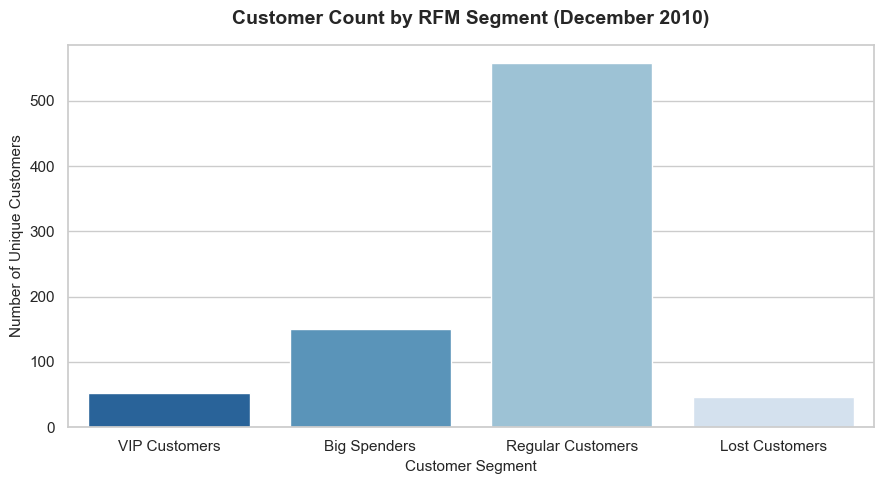

In [14]:
plt.figure(figsize=(9, 5))
sns.set_theme(style='whitegrid')

sns.countplot(
    data=RFM, 
    x='Segment', 
    hue='Segment',       
    legend=False,       
    order=['VIP Customers', 'Big Spenders', 'Regular Customers', 'Lost Customers'],
    palette='Blues_r'
)

plt.title('Customer Count by RFM Segment (December 2010)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Customer Segment', fontsize=11)
plt.ylabel('Number of Unique Customers', fontsize=11)

plt.tight_layout()
plt.savefig('Customer Count by RFM Segment (December 2010).png',bbox_inches='tight')
plt.show()

In [ ]:
#K-Means Clustering

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [ ]:
#1: PREPARE AND SCALE THE DATA FOR K-MEANS

In [16]:
RFM_numeric = RFM[['Recency', 'Frequency', 'Monetary']].copy()

RFM_log = np.log1p(RFM_numeric)

scaler = StandardScaler()
RFM_scaled = scaler.fit_transform(RFM_log)

In [ ]:
#2: RUN THE K-MEANS ALGORITHM

In [17]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(RFM_scaled)

RFM['Cluster'] = kmeans.labels_

RFM['Cluster'] = RFM['Cluster'].apply(lambda x: f'Cluster {x}')

In [ ]:
#3: ANALYZE THE CLUSTER CHARACTERISTICS

In [19]:
print("--- Average RFM Values per Data-Driven Cluster ---")
cluster_summary = RFM.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
print(cluster_summary.round(1))
print("\n")

--- Average RFM Values per Data-Driven Cluster ---
           Recency  Frequency  Monetary
Cluster                                
Cluster 0      7.1        4.1      92.1
Cluster 1     16.4        9.3     154.0
Cluster 2     17.0        2.4      39.2
Cluster 3      6.4       51.7    1165.5




In [ ]:
#4: VISUALIZE THE DATA-DRIVEN CLUSTERS

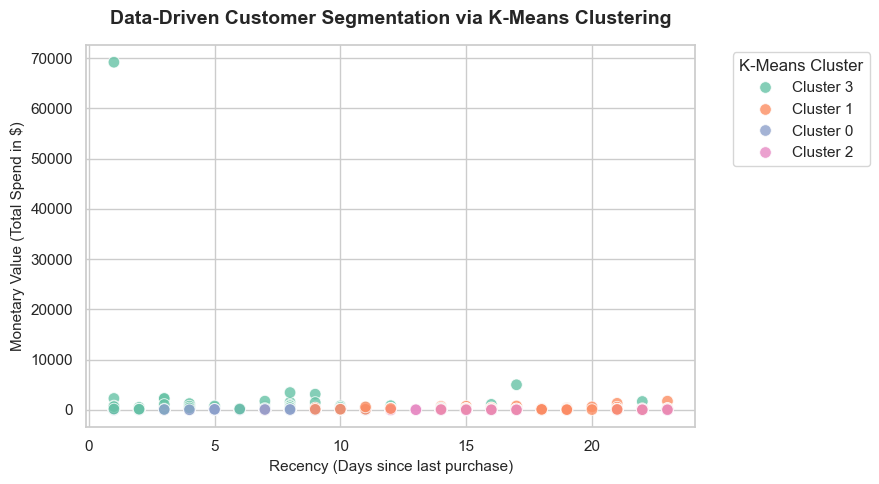

In [22]:
plt.figure(figsize=(9,5))
sns.set_theme(style='whitegrid')

sns.scatterplot(
    data=RFM, 
    x='Recency', 
    y='Monetary', 
    hue='Cluster', 
    palette='Set2', 
    alpha=0.8,
    s=70  # Marker size
)

# Label the chart 
plt.title('Data-Driven Customer Segmentation via K-Means Clustering', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Recency (Days since last purchase)', fontsize=11)
plt.ylabel('Monetary Value (Total Spend in $)', fontsize=11)


plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='K-Means Cluster')

plt.tight_layout()
plt.show()